# 🧠 Fusion Model Validation — CREMA-D VideoFlash

**Pipeline:** Face (ResNet18) + Audio (AudioNet) → Weighted Fusion → Emotion Label  
**Dataset:** CREMA-D VideoFlash (7443 `.flv` files)  
**Metrics:** Per-class Accuracy, Macro F1, Confusion Matrix, Face/Audio/Fusion comparison

---
### Architecture Overview
- **Face model** — ResNet18 fine-tuned on 7 emotion classes (BGR → 224×224 → ImageNet-normalised)
- **Audio model** — Bidirectional TCN (AudioNet) on 39-dim MFCCs, 215 frames (~6.88 s)
- **Fusion** — Weighted average: `0.60 × face_probs + 0.40 × audio_probs`
- **Head pose** — MediaPipe FaceLandmarker for engagement scoring (yaw/pitch/roll)

## 1. Install Dependencies

In [4]:
%%capture
!pip install mediapipe librosa scikit-learn seaborn tqdm --quiet

# Verify ffmpeg is present (needed to decode .flv via cv2 / librosa)
import shutil
print('ffmpeg:', shutil.which('ffmpeg'))

## 2. Imports & Constants

In [5]:
import os, glob, re, warnings, time, traceback
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import librosa
import tensorflow as tf
import mediapipe as mp
from mediapipe.tasks.python import vision
import math
from torchvision import models
from keras.layers import (
    Layer, Activation, Conv1D, SpatialDropout1D,
    Add, GlobalAveragePooling1D, BatchNormalization,
    Dense, Input,
)
from keras.models import Model
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

# ─── Paths ────────────────────────────────────────────────────────────────────
VIDEO_DIR         = '/kaggle/input/datasets/sandipbiswal711/crema-d-videoflash/crema-d-mirror-main-VideoFlash/VideoFlash'
FACE_MODEL_PATH   = '/kaggle/input/models/sandipbiswal711/pretrained-models/pytorch/default/1/face_emotion_model.pth'
AUDIO_MODEL_PATH  = '/kaggle/input/models/sandipbiswal711/pretrained-models/pytorch/default/1/audio_emotion_model.keras'
MEDIAPIPE_PATH    = '/kaggle/input/models/sandipbiswal711/pretrained-models/pytorch/default/1/blaze_face_short_range.tflite'
LANDMARKER_PATH   = '/kaggle/input/models/sandipbiswal711/pretrained-models/pytorch/default/1/face_landmarker.task'

# ─── Emotion config (must match training order) ───────────────────────────────
EMOTIONS = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']
NUM_CLASSES = len(EMOTIONS)

# ─── CREMA-D emotion code → label mapping ────────────────────────────────────
# Filename format: <actorID>_<sentence>_<EMOTION>_<level>.flv
# CREMA-D codes: ANG DIS FEA HAP NEU SAD (no SUR in CREMA-D)
CREMD_CODE_MAP = {
    'ANG': 'Angry',
    'DIS': 'Disgust',
    'FEA': 'Fear',
    'HAP': 'Happy',
    'NEU': 'Neutral',
    'SAD': 'Sad',
}

# ─── Audio / MFCC config (exact match to training) ───────────────────────────
SAMPLE_RATE       = 16000
N_MFCC            = 39
N_FFT             = 2048
HOP_LENGTH        = 512
AUDIO_MODEL_FRAMES = 215   # fixed input length AudioNet was trained on

# ─── Fusion weights ───────────────────────────────────────────────────────────
FACE_WEIGHT  = 0.60
AUDIO_WEIGHT = 0.40

# ─── ImageNet normalisation ───────────────────────────────────────────────────
_IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
_IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

# ─── Head pose thresholds ─────────────────────────────────────────────────────
YAW_ENGAGED    = 15
YAW_AWAY       = 30
PITCH_UP_MAX   = 20
PITCH_DOWN_MAX = 25
ROLL_MAX       = 20

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
print(f'TF version: {tf.__version__}')
print(f'Video dir exists: {os.path.isdir(VIDEO_DIR)}')
print(f'Total .flv files: {len(glob.glob(os.path.join(VIDEO_DIR, "*.flv")))}')

Device: cuda
TF version: 2.19.0
Video dir exists: True
Total .flv files: 7442


## 3. AudioNet Architecture (exact replica from models.py)

In [6]:
class ReverseLayer(Layer):
    def call(self, x):
        return tf.reverse(x, axis=[1])

class SigmoidGateLayer(Layer):
    def call(self, inputs):
        original_x, gated = inputs
        return tf.multiply(original_x, tf.sigmoid(gated))

class ExpandDimsLayer(Layer):
    def call(self, x):
        return tf.expand_dims(x, axis=1)

class ConcatLayer(Layer):
    def call(self, inputs):
        return tf.concat(inputs, axis=-2)


def Temporal_Aware_Block(x, i, activation, nb_filters, kernel_size, dropout_rate=0.1):
    original_x = x
    out = Conv1D(filters=nb_filters, kernel_size=kernel_size,
                 dilation_rate=i, padding='causal')(x)
    out = BatchNormalization()(out)
    out = Activation(activation)(out)
    out = SpatialDropout1D(dropout_rate)(out)
    out = Conv1D(filters=nb_filters, kernel_size=kernel_size,
                 dilation_rate=i, padding='causal')(out)
    out = BatchNormalization()(out)
    out = Activation(activation)(out)
    out = SpatialDropout1D(dropout_rate)(out)
    if original_x.shape[-1] != nb_filters:
        original_x = Conv1D(filters=nb_filters, kernel_size=1, padding='same')(original_x)
    return SigmoidGateLayer()([original_x, out])


AUDIONET_CUSTOM_OBJECTS = {
    'ReverseLayer':     ReverseLayer,
    'SigmoidGateLayer': SigmoidGateLayer,
    'ExpandDimsLayer':  ExpandDimsLayer,
    'ConcatLayer':      ConcatLayer,
}

print('AudioNet custom layers defined ✓')

AudioNet custom layers defined ✓


## 4. Model Loaders

In [7]:
# ─── Face model (ResNet18, 7-class) ──────────────────────────────────────────
def load_face_model(path):
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    checkpoint = torch.load(path, map_location='cpu', weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    return model.to(DEVICE)


# ─── Audio model (AudioNet) ───────────────────────────────────────────────────
def load_audio_model(path):
    return tf.keras.models.load_model(path, custom_objects=AUDIONET_CUSTOM_OBJECTS)


# ─── MediaPipe face detector ──────────────────────────────────────────────────
def load_face_detector(path):
    options = vision.FaceDetectorOptions(
        base_options=mp.tasks.BaseOptions(model_asset_path=path),
        running_mode=vision.RunningMode.IMAGE,
        min_detection_confidence=0.5,
    )
    return vision.FaceDetector.create_from_options(options)


# ─── MediaPipe face landmarker ────────────────────────────────────────────────
def load_face_landmarker(path):
    options = vision.FaceLandmarkerOptions(
        base_options=mp.tasks.BaseOptions(model_asset_path=path),
        running_mode=vision.RunningMode.IMAGE,
        output_face_blendshapes=False,
        output_facial_transformation_matrixes=True,
        num_faces=1,
    )
    return vision.FaceLandmarker.create_from_options(options)


print('Loading models...')
t0 = time.time()

face_model     = load_face_model(FACE_MODEL_PATH)
print(f'  ✓ Face model loaded  ({time.time()-t0:.1f}s)')

audio_model    = load_audio_model(AUDIO_MODEL_PATH)
print(f'  ✓ Audio model loaded ({time.time()-t0:.1f}s)')

face_detector  = load_face_detector(MEDIAPIPE_PATH)
print(f'  ✓ Face detector loaded ({time.time()-t0:.1f}s)')

face_landmarker = load_face_landmarker(LANDMARKER_PATH)
print(f'  ✓ Face landmarker loaded ({time.time()-t0:.1f}s)')
print('All models ready.')

Loading models...
  ✓ Face model loaded  (1.4s)


I0000 00:00:1773681908.806329      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15447 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


  ✓ Audio model loaded (4.3s)
  ✓ Face detector loaded (4.3s)
  ✓ Face landmarker loaded (4.4s)
All models ready.


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1773681911.662667     176 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773681911.673978     179 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
W0000 00:00:1773681911.728538     183 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773681911.760199     183 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


## 5. Preprocessing & Inference Helpers (exact replica from models.py + scoring_engine.py)

In [8]:
# ─── Face preprocessing ───────────────────────────────────────────────────────
def preprocess_face(face_bgr):
    """BGR crop → normalised (1, 3, 224, 224) torch tensor on DEVICE."""
    face = cv2.resize(face_bgr, (224, 224))
    face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
    face = face.astype(np.float32) / 255.0
    face = torch.tensor(face).permute(2, 0, 1)
    face = (face - _IMAGENET_MEAN) / _IMAGENET_STD
    return face.unsqueeze(0).to(DEVICE)


# ─── MFCC extraction ──────────────────────────────────────────────────────────
def extract_mfcc(audio_pcm):
    """Raw PCM → (215, 39) float32. Pads/truncates to AUDIO_MODEL_FRAMES."""
    mfcc   = librosa.feature.mfcc(
        y=audio_pcm, sr=SAMPLE_RATE,
        n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH
    )
    frames = mfcc.T.astype(np.float32)
    T      = frames.shape[0]
    if T >= AUDIO_MODEL_FRAMES:
        frames = frames[:AUDIO_MODEL_FRAMES]
    else:
        pad    = np.zeros((AUDIO_MODEL_FRAMES - T, N_MFCC), dtype=np.float32)
        frames = np.concatenate([frames, pad], axis=0)
    return frames


# ─── Audio inference ──────────────────────────────────────────────────────────
def predict_audio_emotion(audio_pcm):
    """Raw PCM → (label, probs_list) or (None, None)."""
    if audio_pcm is None or len(audio_pcm) == 0:
        return None, None
    mfcc  = extract_mfcc(audio_pcm)
    probs = audio_model.predict(mfcc[np.newaxis], verbose=0)[0]
    idx   = int(np.argmax(probs))
    return EMOTIONS[idx], probs.tolist()


# ─── Fusion ───────────────────────────────────────────────────────────────────
def fuse_predictions(face_probs, audio_probs):
    """Weighted average fusion → (label, confidence_pct, fused_probs)."""
    fp = np.array(face_probs, dtype=np.float32)
    if audio_probs is not None:
        ap    = np.array(audio_probs, dtype=np.float32)
        fused = FACE_WEIGHT * fp + AUDIO_WEIGHT * ap
    else:
        fused = fp
    fused /= fused.sum()
    idx = int(np.argmax(fused))
    return EMOTIONS[idx], float(fused[idx]) * 100, fused.tolist()


# ─── Head pose helpers ────────────────────────────────────────────────────────
def rotation_matrix_to_euler(R):
    """3×3 rotation matrix → (pitch, yaw, roll) in degrees."""
    sy = math.sqrt(R[0, 0]**2 + R[1, 0]**2)
    singular = sy < 1e-6
    if not singular:
        pitch = math.atan2( R[2, 1], R[2, 2])
        yaw   = math.atan2(-R[2, 0], sy)
        roll  = math.atan2( R[1, 0], R[0, 0])
    else:
        pitch = math.atan2(-R[1, 2], R[1, 1])
        yaw   = math.atan2(-R[2, 0], sy)
        roll  = 0
    return math.degrees(pitch), math.degrees(yaw), math.degrees(roll)


def compute_head_engagement_tick(yaw, pitch, roll, face_present):
    """Score 0–100 for a single frame. Returns (score, status, details)."""
    if not face_present:
        return 0.0, 'No Face', {}
    score   = 100.0
    abs_yaw = abs(yaw)
    if abs_yaw <= YAW_ENGAGED:
        yaw_penalty = 0
    elif abs_yaw <= YAW_AWAY:
        yaw_penalty = (abs_yaw - YAW_ENGAGED) / (YAW_AWAY - YAW_ENGAGED) * 40
    else:
        yaw_penalty = 40 + min(40, (abs_yaw - YAW_AWAY) * 2)
    score -= yaw_penalty
    if pitch > PITCH_UP_MAX:
        score -= min(30, (pitch - PITCH_UP_MAX) * 1.5)
    elif pitch < -PITCH_DOWN_MAX:
        score -= min(30, (-pitch - PITCH_DOWN_MAX) * 1.5)
    abs_roll = abs(roll)
    if abs_roll > ROLL_MAX:
        score -= min(20, (abs_roll - ROLL_MAX) * 1.0)
    score  = max(0.0, min(100.0, score))
    status = 'Engaged' if score >= 75 else 'Partial' if score >= 45 else 'Distracted'
    return score, status, {'yaw': yaw, 'pitch': pitch, 'roll': roll}


print('All helpers defined ✓')

All helpers defined ✓


## 6. Dataset Parsing — CREMA-D Filename → Ground Truth

In [9]:
def parse_crema_filename(filepath):
    """
    Parse CREMA-D filename: <actorID>_<sentence>_<EMOTION>_<level>.flv
    Returns (actor_id, sentence, emotion_label) or (None, None, None) on failure.
    """
    fname = os.path.splitext(os.path.basename(filepath))[0]
    parts = fname.split('_')
    if len(parts) < 3:
        return None, None, None
    actor_id   = parts[0]
    sentence   = parts[1]
    emotion_cd = parts[2].upper()
    label      = CREMD_CODE_MAP.get(emotion_cd)
    return actor_id, sentence, label


# Build file list with ground truth labels
all_files = sorted(glob.glob(os.path.join(VIDEO_DIR, '*.flv')))

dataset = []
skipped = 0
for fp in all_files:
    actor_id, sentence, label = parse_crema_filename(fp)
    if label is None:
        skipped += 1
        continue
    dataset.append({'filepath': fp, 'actor_id': actor_id,
                    'sentence': sentence, 'gt_label': label})

df_meta = pd.DataFrame(dataset)
print(f'Total files found  : {len(all_files)}')
print(f'Parsed successfully: {len(df_meta)}')
print(f'Skipped (unknown)  : {skipped}')
print('\nGround truth distribution:')
print(df_meta['gt_label'].value_counts().to_string())

Total files found  : 7442
Parsed successfully: 7442
Skipped (unknown)  : 0

Ground truth distribution:
gt_label
Angry      1271
Disgust    1271
Fear       1271
Happy      1271
Sad        1271
Neutral    1087


## 7. Per-video Inference Pipeline

In [10]:
# ─── Configuration ────────────────────────────────────────────────────────────
# Number of uniformly-spaced frames to sample per video for face inference.
# More frames = better accuracy but slower. 5-10 is a good balance.
N_FACE_FRAMES   = 8

# Whether to run head pose estimation per frame (adds ~15ms/frame)
RUN_HEAD_POSE   = True

# Max videos to evaluate. Set to None to run the full dataset.
MAX_VIDEOS      = None   # e.g. 500 for a quick run


def extract_audio_from_video(filepath):
    """
    Extract PCM audio from a video file using librosa.
    Returns (pcm_float32, sample_rate) or (None, None).
    """
    try:
        pcm, sr = librosa.load(filepath, sr=SAMPLE_RATE, mono=True)
        return pcm.astype(np.float32), sr
    except Exception:
        return None, None


def sample_frames(filepath, n=N_FACE_FRAMES):
    """
    Uniformly sample `n` BGR frames from a video file.
    Returns list of numpy arrays (BGR).
    """
    cap    = cv2.VideoCapture(filepath)
    total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return []
    indices = np.linspace(0, total - 1, n, dtype=int)
    frames  = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()
        if ret and frame is not None:
            frames.append(frame)
    cap.release()
    return frames


def run_face_inference_on_frames(bgr_frames):
    """
    Detect faces and run emotion inference on each sampled frame.
    Returns:
      face_probs_all  : list of 7-float prob vectors (one per detected face crop)
      head_scores_all : list of (score, status, angles) dicts
    """
    face_probs_all  = []
    head_scores_all = []

    for bgr in bgr_frames:
        rgb      = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)

        # ── Face detection ────────────────────────────────────────────────────
        try:
            det_result = face_detector.detect(mp_image)
        except Exception:
            continue

        if not det_result.detections:
            continue

        for detection in det_result.detections:
            bbox = detection.bounding_box
            x    = max(0, int(bbox.origin_x))
            y    = max(0, int(bbox.origin_y))
            w    = int(bbox.width)
            h    = int(bbox.height)
            crop = bgr[y:y+h, x:x+w]
            if crop.size == 0 or crop.shape[0] < 8 or crop.shape[1] < 8:
                continue

            # ── Emotion inference ─────────────────────────────────────────────
            try:
                with torch.no_grad():
                    logits = face_model(preprocess_face(crop))
                    probs  = torch.softmax(logits, dim=1)[0].cpu().tolist()
                face_probs_all.append(probs)
            except Exception:
                pass

        # ── Head pose ─────────────────────────────────────────────────────────
        if RUN_HEAD_POSE:
            try:
                lm_result = face_landmarker.detect(mp_image)
                if lm_result.facial_transformation_matrixes:
                    mat   = np.array(lm_result.facial_transformation_matrixes[0])
                    R     = mat[:3, :3]
                    pitch, yaw, roll = rotation_matrix_to_euler(R)
                    score, status, angles = compute_head_engagement_tick(
                        yaw, pitch, roll, face_present=True
                    )
                    head_scores_all.append({
                        'score': score, 'status': status,
                        'yaw': yaw, 'pitch': pitch, 'roll': roll,
                        'face_present': True
                    })
            except Exception:
                pass

    return face_probs_all, head_scores_all


def aggregate_face_probs(face_probs_all):
    """Average per-frame face probs → single (7,) vector."""
    if not face_probs_all:
        return None
    return np.mean(face_probs_all, axis=0).tolist()


def process_video(row):
    """
    Full per-video inference pipeline.
    Returns a result dict.
    """
    filepath = row['filepath']
    result   = {
        'filepath':       filepath,
        'gt_label':       row['gt_label'],
        'actor_id':       row['actor_id'],
        'face_label':     None,
        'audio_label':    None,
        'fused_label':    None,
        'face_probs':     None,
        'audio_probs':    None,
        'fused_probs':    None,
        'face_confidence': None,
        'head_score':     None,
        'head_status':    None,
        'n_face_detections': 0,
        'error':          None,
    }

    try:
        # ── 1. Sample frames & run face/head inference ─────────────────────
        bgr_frames             = sample_frames(filepath)
        face_probs_all, head_ticks = run_face_inference_on_frames(bgr_frames)
        agg_face_probs         = aggregate_face_probs(face_probs_all)
        result['n_face_detections'] = len(face_probs_all)

        if agg_face_probs is not None:
            idx  = int(np.argmax(agg_face_probs))
            result['face_label']      = EMOTIONS[idx]
            result['face_probs']      = agg_face_probs
            result['face_confidence'] = float(agg_face_probs[idx]) * 100

        if head_ticks:
            result['head_score']  = float(np.mean([h['score']  for h in head_ticks]))
            # Most common status
            statuses              = [h['status'] for h in head_ticks]
            result['head_status'] = max(set(statuses), key=statuses.count)

        # ── 2. Extract audio & run AudioNet inference ──────────────────────
        audio_pcm, _  = extract_audio_from_video(filepath)
        audio_label, audio_probs = predict_audio_emotion(audio_pcm)
        result['audio_label'] = audio_label
        result['audio_probs'] = audio_probs

        # ── 3. Fusion ──────────────────────────────────────────────────────
        face_p  = agg_face_probs if agg_face_probs is not None else [1/NUM_CLASSES]*NUM_CLASSES
        fused_label, fused_conf, fused_probs = fuse_predictions(face_p, audio_probs)
        result['fused_label']  = fused_label
        result['fused_probs']  = fused_probs

    except Exception as e:
        result['error'] = str(e)

    return result


print('Pipeline defined ✓')

Pipeline defined ✓


## 8. Run Evaluation

In [11]:
eval_data = df_meta.copy()
if MAX_VIDEOS is not None:
    eval_data = eval_data.sample(n=min(MAX_VIDEOS, len(eval_data)),
                                  random_state=42).reset_index(drop=True)

print(f'Evaluating {len(eval_data)} videos...')

results = []
errors  = []

for _, row in tqdm(eval_data.iterrows(), total=len(eval_data), desc='Processing'):
    res = process_video(row)
    results.append(res)
    if res['error']:
        errors.append((row['filepath'], res['error']))

df_results = pd.DataFrame(results)

print(f'\nDone. Errors: {len(errors)}/{len(results)}')
if errors:
    print('First 5 errors:')
    for fp, err in errors[:5]:
        print(f'  {os.path.basename(fp)}: {err}')

Evaluating 7442 videos...


Processing:   0%|          | 0/7442 [00:00<?, ?it/s]

I0000 00:00:1773681963.883990     155 service.cc:152] XLA service 0x7a082c004a00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773681963.884031     155 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1773681964.546809     155 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1773681967.061885     155 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



Done. Errors: 0/7442


## 9. Compute Metrics

In [12]:
# Filter CREMA-D labels to those present in our EMOTIONS list
# (CREMA-D has no 'Surprise' — we still evaluate on its 6 classes)
valid_mask   = df_results['gt_label'].notna()
df_valid     = df_results[valid_mask].copy()

# ─── Ground truth ─────────────────────────────────────────────────────────────
y_true = df_valid['gt_label'].tolist()

# ─── Predictions (fallback to majority class on None) ─────────────────────────
FALLBACK = 'Neutral'

y_face  = [x if x is not None else FALLBACK for x in df_valid['face_label'].tolist()]
y_audio = [x if x is not None else FALLBACK for x in df_valid['audio_label'].tolist()]
y_fused = [x if x is not None else FALLBACK for x in df_valid['fused_label'].tolist()]

# ─── Accuracies ───────────────────────────────────────────────────────────────
acc_face  = accuracy_score(y_true, y_face)  * 100
acc_audio = accuracy_score(y_true, y_audio) * 100
acc_fused = accuracy_score(y_true, y_fused) * 100

# ─── Macro F1 ─────────────────────────────────────────────────────────────────
present_labels = sorted(df_valid['gt_label'].unique().tolist())

f1_face  = f1_score(y_true, y_face,  average='macro', labels=present_labels, zero_division=0) * 100
f1_audio = f1_score(y_true, y_audio, average='macro', labels=present_labels, zero_division=0) * 100
f1_fused = f1_score(y_true, y_fused, average='macro', labels=present_labels, zero_division=0) * 100

print('=' * 55)
print(f"{'Modality':<18} {'Accuracy':>12} {'Macro F1':>12}")
print('-' * 55)
print(f"{'Face (ResNet18)':<18} {acc_face:>11.2f}% {f1_face:>11.2f}%")
print(f"{'Audio (AudioNet)':<18} {acc_audio:>11.2f}% {f1_audio:>11.2f}%")
print(f"{'Fusion (0.6+0.4)':<18} {acc_fused:>11.2f}% {f1_fused:>11.2f}%")
print('=' * 55)

# Face–Audio agreement
both_valid    = df_valid['face_label'].notna() & df_valid['audio_label'].notna()
if both_valid.sum() > 0:
    agreement = (df_valid.loc[both_valid, 'face_label'] ==
                 df_valid.loc[both_valid, 'audio_label']).mean() * 100
    print(f'\nFace–Audio agreement (on {both_valid.sum()} paired samples): {agreement:.1f}%')

# Face detection rate
face_det_rate = df_valid['face_label'].notna().mean() * 100
print(f'Face detection rate : {face_det_rate:.1f}%')
print(f'Total valid samples : {len(df_valid)}')

Modality               Accuracy     Macro F1
-------------------------------------------------------
Face (ResNet18)          37.89%       34.76%
Audio (AudioNet)         16.64%       12.39%
Fusion (0.6+0.4)         35.23%       32.56%

Face–Audio agreement (on 7441 paired samples): 26.3%
Face detection rate : 100.0%
Total valid samples : 7442


## 10. Per-class Report

In [13]:
print('\n───── Face Model ─────')
print(classification_report(y_true, y_face, labels=present_labels, zero_division=0))

print('\n───── Audio Model ─────')
print(classification_report(y_true, y_audio, labels=present_labels, zero_division=0))

print('\n───── Fusion Model ─────')
print(classification_report(y_true, y_fused, labels=present_labels, zero_division=0))


───── Face Model ─────
              precision    recall  f1-score   support

       Angry       0.25      0.29      0.27      1271
     Disgust       0.98      0.04      0.08      1271
        Fear       0.48      0.16      0.24      1271
       Happy       0.76      0.84      0.80      1271
     Neutral       0.29      0.65      0.41      1087
         Sad       0.27      0.33      0.30      1271

   micro avg       0.39      0.38      0.38      7442
   macro avg       0.51      0.39      0.35      7442
weighted avg       0.51      0.38      0.35      7442


───── Audio Model ─────
              precision    recall  f1-score   support

       Angry       0.65      0.18      0.29      1271
     Disgust       0.17      0.07      0.10      1271
        Fear       0.25      0.00      0.00      1271
       Happy       0.17      0.01      0.02      1271
     Neutral       0.18      0.79      0.29      1087
         Sad       0.08      0.03      0.04      1271

   micro avg       0.20     

## 11. Confusion Matrices

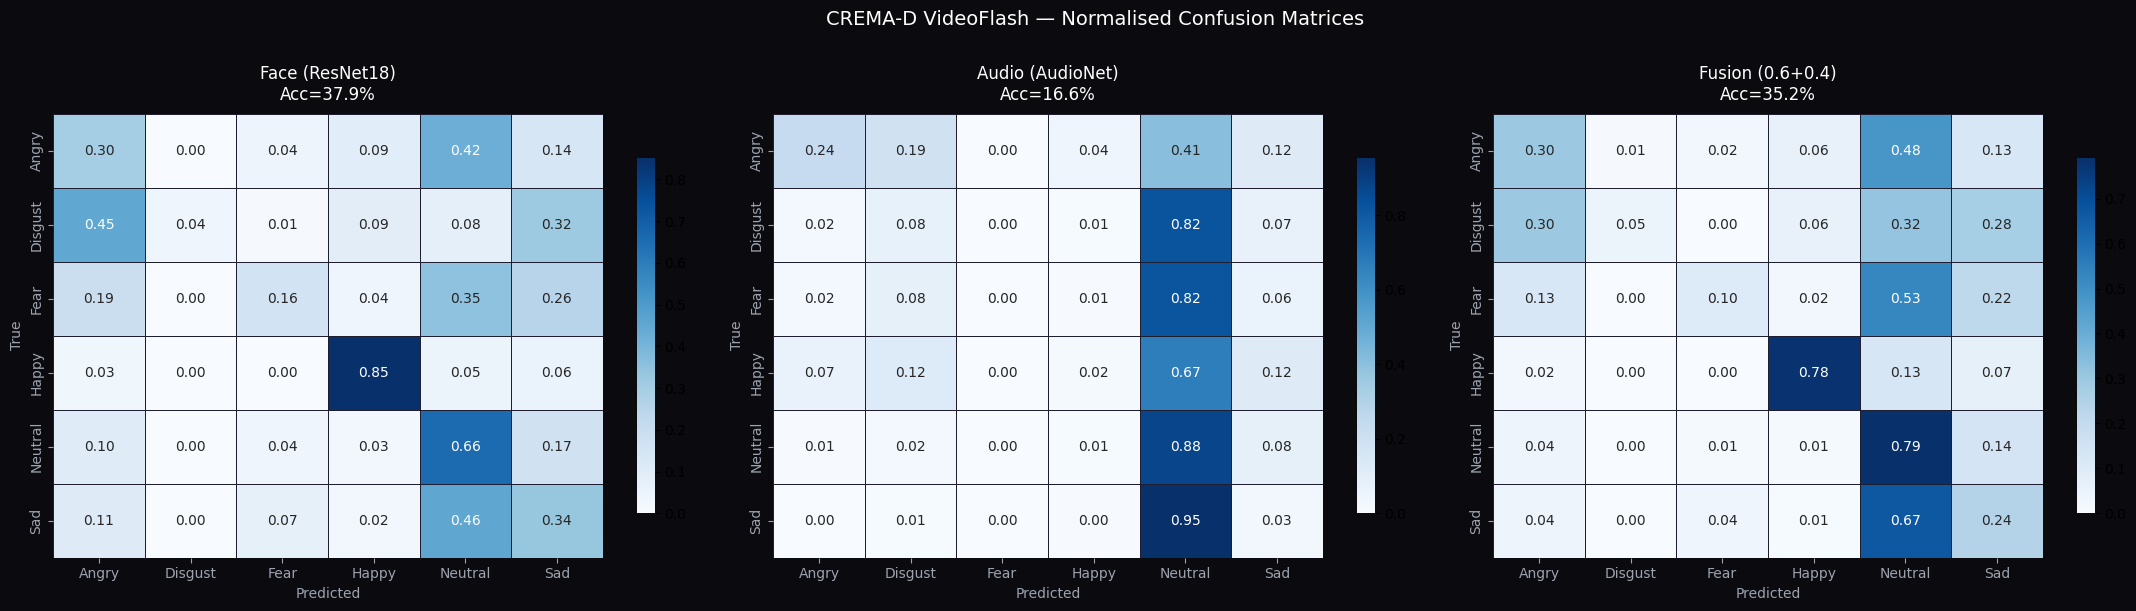

Saved: confusion_matrices.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.patch.set_facecolor('#0a0a0f')

PLOT_LABELS = present_labels

CONF_PAIRS = [
    (y_face,  'Face (ResNet18)',   axes[0]),
    (y_audio, 'Audio (AudioNet)',  axes[1]),
    (y_fused, 'Fusion (0.6+0.4)', axes[2]),
]

for y_pred, title, ax in CONF_PAIRS:
    cm = confusion_matrix(y_true, y_pred, labels=PLOT_LABELS, normalize='true')
    sns.heatmap(
        cm, annot=True, fmt='.2f', cmap='Blues',
        xticklabels=PLOT_LABELS, yticklabels=PLOT_LABELS,
        ax=ax, linewidths=0.4, linecolor='#1e1e30',
        cbar_kws={'shrink': 0.8}
    )
    acc = accuracy_score(y_true, y_pred) * 100
    ax.set_title(f'{title}\nAcc={acc:.1f}%', color='white', fontsize=12, pad=10)
    ax.set_xlabel('Predicted', color='#9ca3af')
    ax.set_ylabel('True', color='#9ca3af')
    ax.tick_params(colors='#9ca3af')
    ax.set_facecolor('#13131f')
    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2a3d')

plt.suptitle('CREMA-D VideoFlash — Normalised Confusion Matrices',
             color='white', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight',
            facecolor='#0a0a0f')
plt.show()
print('Saved: confusion_matrices.png')

## 12. Per-class Accuracy Comparison Chart

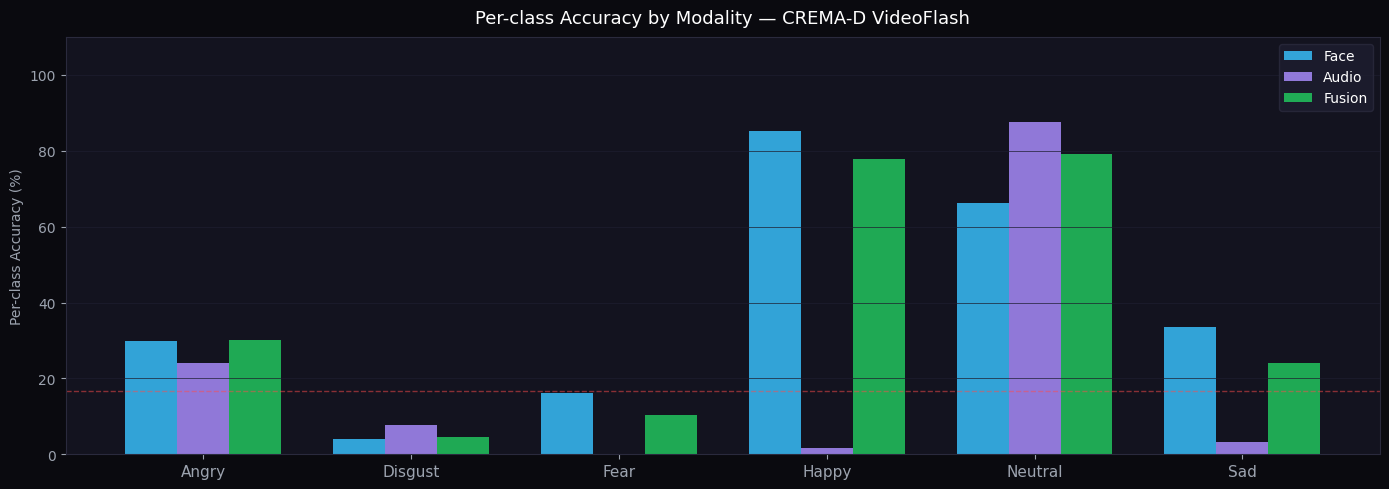

Saved: per_class_accuracy.png


In [15]:
from sklearn.metrics import confusion_matrix as _cm

def per_class_acc(y_t, y_p, labels):
    cm  = _cm(y_t, y_p, labels=labels)
    return dict(zip(labels, cm.diagonal() / cm.sum(axis=1).clip(1) * 100))

pca_face  = per_class_acc(y_true, y_face,  PLOT_LABELS)
pca_audio = per_class_acc(y_true, y_audio, PLOT_LABELS)
pca_fused = per_class_acc(y_true, y_fused, PLOT_LABELS)

x     = np.arange(len(PLOT_LABELS))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#0a0a0f')
ax.set_facecolor('#13131f')

bars_face  = ax.bar(x - width, [pca_face[l]  for l in PLOT_LABELS], width,
                    color='#38bdf8', alpha=0.85, label='Face')
bars_audio = ax.bar(x,          [pca_audio[l] for l in PLOT_LABELS], width,
                    color='#a78bfa', alpha=0.85, label='Audio')
bars_fused = ax.bar(x + width,  [pca_fused[l] for l in PLOT_LABELS], width,
                    color='#22C55E', alpha=0.85, label='Fusion')

ax.set_xticks(x)
ax.set_xticklabels(PLOT_LABELS, color='#9ca3af', fontsize=11)
ax.set_ylabel('Per-class Accuracy (%)', color='#9ca3af')
ax.set_ylim(0, 110)
ax.yaxis.label.set_color('#9ca3af')
ax.tick_params(colors='#9ca3af')
for spine in ax.spines.values():
    spine.set_edgecolor('#2a2a3d')
ax.legend(facecolor='#1e1e30', edgecolor='#2a2a3d', labelcolor='white', fontsize=10)
ax.set_title('Per-class Accuracy by Modality — CREMA-D VideoFlash',
             color='white', fontsize=13, pad=10)
ax.axhline(y=100/len(PLOT_LABELS), color='#FF4B4B', linestyle='--',
           alpha=0.5, linewidth=1, label='Chance')
ax.grid(axis='y', color='#1e1e30', linewidth=0.5)

plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150, bbox_inches='tight',
            facecolor='#0a0a0f')
plt.show()
print('Saved: per_class_accuracy.png')

## 13. Fusion vs Face-only vs Audio-only — Overall Summary Bar

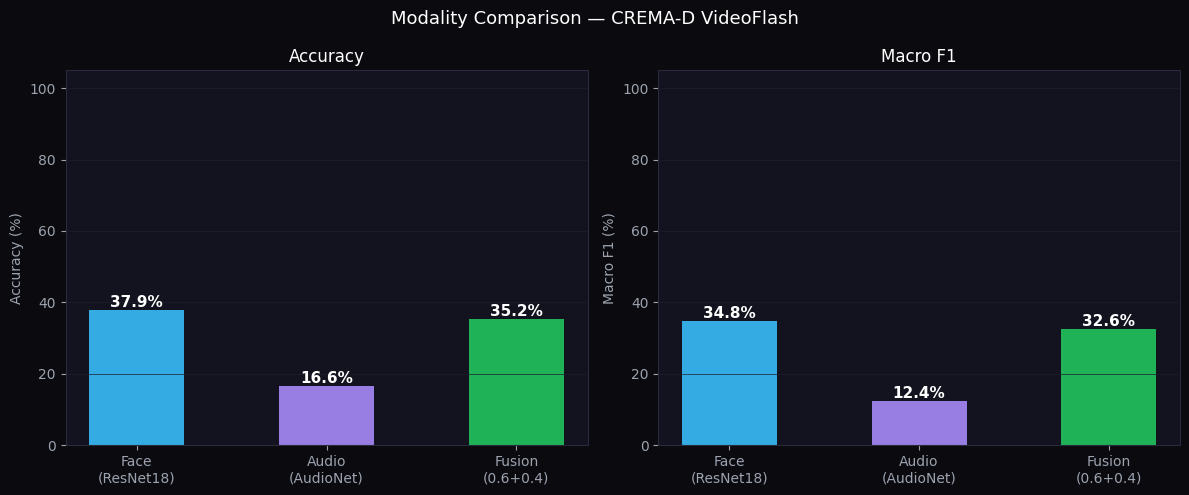

Saved: modality_comparison.png


In [16]:
summary = {
    'Modality':  ['Face\n(ResNet18)', 'Audio\n(AudioNet)', 'Fusion\n(0.6+0.4)'],
    'Accuracy':  [acc_face, acc_audio, acc_fused],
    'Macro F1':  [f1_face,  f1_audio,  f1_fused],
    'Color':     ['#38bdf8', '#a78bfa', '#22C55E'],
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('#0a0a0f')

for ax, metric in zip(axes, ['Accuracy', 'Macro F1']):
    ax.set_facecolor('#13131f')
    bars = ax.bar(summary['Modality'], summary[metric],
                  color=summary['Color'], alpha=0.9, width=0.5)
    for bar, val in zip(bars, summary[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                f'{val:.1f}%', ha='center', color='white', fontsize=11, fontweight='bold')
    ax.set_ylim(0, 105)
    ax.set_ylabel(f'{metric} (%)', color='#9ca3af')
    ax.set_title(metric, color='white', fontsize=12)
    ax.tick_params(colors='#9ca3af')
    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2a3d')
    ax.grid(axis='y', color='#1e1e30', linewidth=0.5)

fig.suptitle('Modality Comparison — CREMA-D VideoFlash', color='white', fontsize=13)
plt.tight_layout()
plt.savefig('modality_comparison.png', dpi=150, bbox_inches='tight',
            facecolor='#0a0a0f')
plt.show()
print('Saved: modality_comparison.png')

## 14. Head Engagement Analysis

Samples with head pose data: 7441
Mean head engagement score : 100.0
Std head engagement score  : 0.3

Head status distribution:
head_status
Engaged    100.0


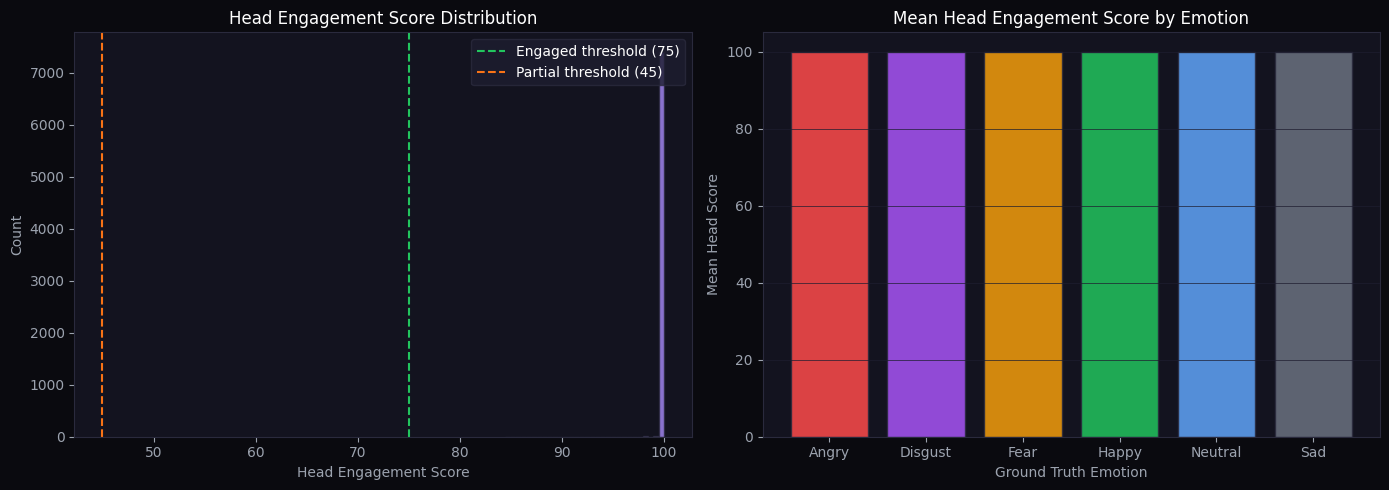

Saved: head_engagement.png


In [17]:
head_df = df_valid.dropna(subset=['head_score'])

if len(head_df) > 0:
    print(f'Samples with head pose data: {len(head_df)}')
    print(f'Mean head engagement score : {head_df["head_score"].mean():.1f}')
    print(f'Std head engagement score  : {head_df["head_score"].std():.1f}')
    print('\nHead status distribution:')
    print(head_df['head_status'].value_counts(normalize=True).mul(100).round(1).to_string())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor('#0a0a0f')

    # Score distribution
    ax = axes[0]
    ax.set_facecolor('#13131f')
    ax.hist(head_df['head_score'], bins=30, color='#a78bfa', alpha=0.8, edgecolor='#2a2a3d')
    ax.axvline(75, color='#22C55E', linestyle='--', label='Engaged threshold (75)')
    ax.axvline(45, color='#F97316', linestyle='--', label='Partial threshold (45)')
    ax.set_xlabel('Head Engagement Score', color='#9ca3af')
    ax.set_ylabel('Count', color='#9ca3af')
    ax.set_title('Head Engagement Score Distribution', color='white')
    ax.tick_params(colors='#9ca3af')
    ax.legend(facecolor='#1e1e30', edgecolor='#2a2a3d', labelcolor='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2a3d')

    # Engagement score vs. fusion accuracy per emotion
    ax = axes[1]
    ax.set_facecolor('#13131f')
    emotion_scores = head_df.groupby('gt_label')['head_score'].mean().reindex(PLOT_LABELS)
    colors_emo     = ['#FF4B4B','#A855F7','#F59E0B','#22C55E','#60A5FA','#6B7280','#F97316']
    ax.bar(emotion_scores.index, emotion_scores.values,
           color=[colors_emo[PLOT_LABELS.index(l)] if l in PLOT_LABELS else '#60A5FA'
                  for l in emotion_scores.index],
           alpha=0.85, edgecolor='#2a2a3d')
    ax.set_xlabel('Ground Truth Emotion', color='#9ca3af')
    ax.set_ylabel('Mean Head Score', color='#9ca3af')
    ax.set_title('Mean Head Engagement Score by Emotion', color='white')
    ax.tick_params(colors='#9ca3af')
    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2a3d')
    ax.grid(axis='y', color='#1e1e30', linewidth=0.5)

    plt.tight_layout()
    plt.savefig('head_engagement.png', dpi=150, bbox_inches='tight',
                facecolor='#0a0a0f')
    plt.show()
    print('Saved: head_engagement.png')
else:
    print('No head pose data available — skipping head engagement analysis.')

## 15. Face–Audio Modality Agreement by Emotion

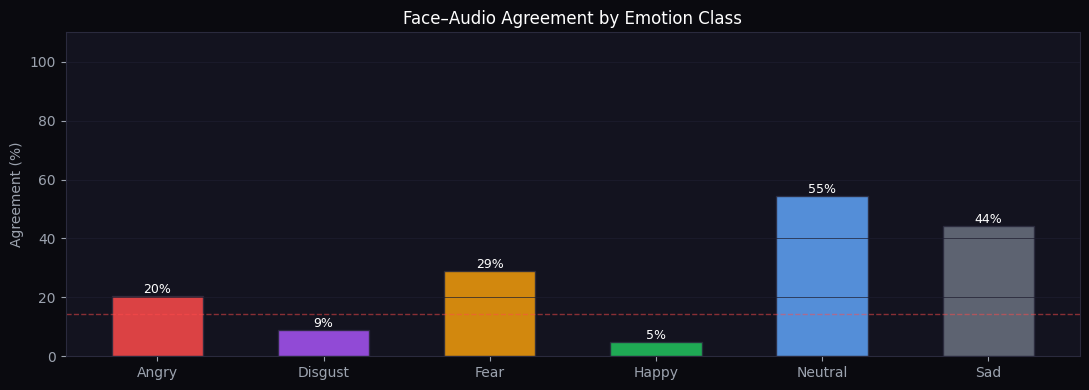

Saved: face_audio_agreement.png


In [18]:
paired = df_valid.dropna(subset=['face_label', 'audio_label'])

if len(paired) > 0:
    paired = paired.copy()
    paired['agree'] = paired['face_label'] == paired['audio_label']
    agree_by_emo    = paired.groupby('gt_label')['agree'].mean().mul(100).reindex(PLOT_LABELS)

    fig, ax = plt.subplots(figsize=(11, 4))
    fig.patch.set_facecolor('#0a0a0f')
    ax.set_facecolor('#13131f')

    colors_emo = ['#FF4B4B','#A855F7','#F59E0B','#22C55E','#60A5FA','#6B7280','#F97316']
    bars = ax.bar(agree_by_emo.index.tolist(), agree_by_emo.values.tolist(),
                  color=[colors_emo[i] for i in range(len(agree_by_emo))],
                  alpha=0.85, edgecolor='#2a2a3d', width=0.55)

    for bar, val in zip(bars, agree_by_emo.values):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2, val + 1,
                    f'{val:.0f}%', ha='center', color='white', fontsize=9)

    ax.axhline(y=100/NUM_CLASSES, color='#FF4B4B', linestyle='--',
               alpha=0.5, linewidth=1)
    ax.set_ylabel('Agreement (%)', color='#9ca3af')
    ax.set_title('Face–Audio Agreement by Emotion Class', color='white', fontsize=12)
    ax.set_ylim(0, 110)
    ax.tick_params(colors='#9ca3af')
    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2a3d')
    ax.grid(axis='y', color='#1e1e30', linewidth=0.5)

    plt.tight_layout()
    plt.savefig('face_audio_agreement.png', dpi=150, bbox_inches='tight',
                facecolor='#0a0a0f')
    plt.show()
    print('Saved: face_audio_agreement.png')
else:
    print('No paired face+audio predictions available.')

## 16. Confidence Distribution

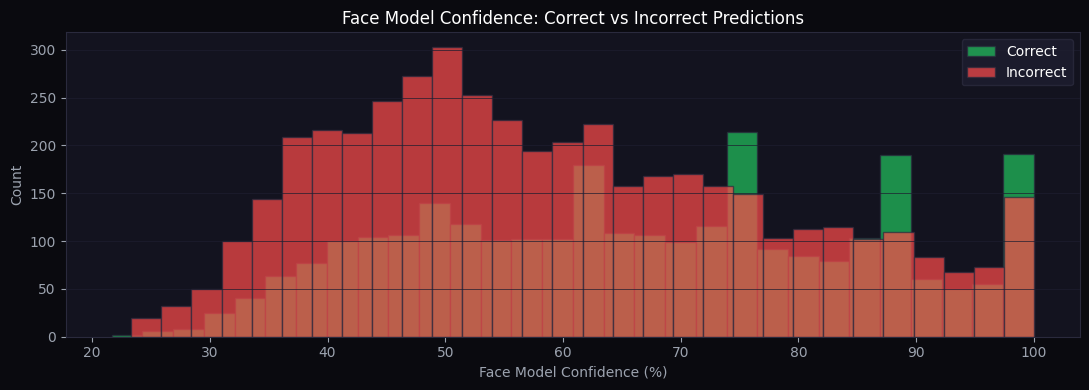

Mean confidence (correct)  : 66.9%
Mean confidence (incorrect): 59.8%


In [19]:
conf_df = df_valid.dropna(subset=['face_confidence'])

if len(conf_df) > 0:
    correct_face  = conf_df['face_label'] == conf_df['gt_label']

    fig, ax = plt.subplots(figsize=(11, 4))
    fig.patch.set_facecolor('#0a0a0f')
    ax.set_facecolor('#13131f')

    ax.hist(conf_df.loc[correct_face,  'face_confidence'], bins=30,
            alpha=0.7, color='#22C55E', label='Correct', edgecolor='#2a2a3d')
    ax.hist(conf_df.loc[~correct_face, 'face_confidence'], bins=30,
            alpha=0.7, color='#FF4B4B', label='Incorrect', edgecolor='#2a2a3d')

    ax.set_xlabel('Face Model Confidence (%)', color='#9ca3af')
    ax.set_ylabel('Count', color='#9ca3af')
    ax.set_title('Face Model Confidence: Correct vs Incorrect Predictions', color='white')
    ax.tick_params(colors='#9ca3af')
    ax.legend(facecolor='#1e1e30', edgecolor='#2a2a3d', labelcolor='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2a3d')
    ax.grid(axis='y', color='#1e1e30', linewidth=0.5)

    plt.tight_layout()
    plt.savefig('confidence_distribution.png', dpi=150, bbox_inches='tight',
                facecolor='#0a0a0f')
    plt.show()

    print(f'Mean confidence (correct)  : {conf_df.loc[correct_face,  "face_confidence"].mean():.1f}%')
    print(f'Mean confidence (incorrect): {conf_df.loc[~correct_face, "face_confidence"].mean():.1f}%')

## 17. Save Results to CSV

In [20]:
# Save a clean results table (drop raw prob columns for readability)
csv_cols = ['filepath', 'actor_id', 'sentence', 'gt_label',
            'face_label', 'audio_label', 'fused_label',
            'face_confidence', 'head_score', 'head_status',
            'n_face_detections', 'error']

# Add sentence col if missing
if 'sentence' not in df_results.columns:
    df_results['sentence'] = df_results['filepath'].apply(
        lambda p: os.path.splitext(os.path.basename(p))[0].split('_')[1]
        if len(os.path.splitext(os.path.basename(p))[0].split('_')) > 1 else ''
    )

save_cols = [c for c in csv_cols if c in df_results.columns]
df_results[save_cols].to_csv('validation_results.csv', index=False)
print('Saved: validation_results.csv')

# Summary table
summary_df = pd.DataFrame({
    'Modality':  ['Face (ResNet18)', 'Audio (AudioNet)', 'Fusion (0.6+0.4)'],
    'Accuracy':  [f'{acc_face:.2f}%',  f'{acc_audio:.2f}%',  f'{acc_fused:.2f}%'],
    'Macro_F1':  [f'{f1_face:.2f}%',   f'{f1_audio:.2f}%',   f'{f1_fused:.2f}%'],
    'n_samples': [len(y_true)] * 3,
})
summary_df.to_csv('validation_summary.csv', index=False)
print('Saved: validation_summary.csv')
print(summary_df.to_string(index=False))

Saved: validation_results.csv
Saved: validation_summary.csv
        Modality Accuracy Macro_F1  n_samples
 Face (ResNet18)   37.89%   34.76%       7442
Audio (AudioNet)   16.64%   12.39%       7442
Fusion (0.6+0.4)   35.23%   32.56%       7442


## 18. Final Summary Dashboard

In [21]:
print('\n' + '═'*60)
print('  FUSION MODEL VALIDATION — CREMA-D VideoFlash')
print('═'*60)
print(f'  Dataset          : CREMA-D VideoFlash')
print(f'  Total samples    : {len(df_valid)}')
print(f'  Classes          : {present_labels}')
print(f'  Face frames/clip : {N_FACE_FRAMES}')
print(f'  Fusion weights   : Face={FACE_WEIGHT}, Audio={AUDIO_WEIGHT}')
print('─'*60)
print(f'  Face  Accuracy   : {acc_face:.2f}%  |  Macro F1: {f1_face:.2f}%')
print(f'  Audio Accuracy   : {acc_audio:.2f}%  |  Macro F1: {f1_audio:.2f}%')
print(f'  FUSION Accuracy  : {acc_fused:.2f}%  |  Macro F1: {f1_fused:.2f}%')
print('─'*60)
lift_acc = acc_fused - max(acc_face, acc_audio)
lift_f1  = f1_fused  - max(f1_face,  f1_audio)
print(f'  Fusion lift (vs best single): Acc {lift_acc:+.2f}%  |  F1 {lift_f1:+.2f}%')
print('═'*60)

if both_valid.sum() > 0:
    print(f'  Face–Audio Agreement : {agreement:.1f}%')
print(f'  Face Detection Rate  : {face_det_rate:.1f}%')
print('═'*60)


════════════════════════════════════════════════════════════
  FUSION MODEL VALIDATION — CREMA-D VideoFlash
════════════════════════════════════════════════════════════
  Dataset          : CREMA-D VideoFlash
  Total samples    : 7442
  Classes          : ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad']
  Face frames/clip : 8
  Fusion weights   : Face=0.6, Audio=0.4
────────────────────────────────────────────────────────────
  Face  Accuracy   : 37.89%  |  Macro F1: 34.76%
  Audio Accuracy   : 16.64%  |  Macro F1: 12.39%
  FUSION Accuracy  : 35.23%  |  Macro F1: 32.56%
────────────────────────────────────────────────────────────
  Fusion lift (vs best single): Acc -2.66%  |  F1 -2.20%
════════════════════════════════════════════════════════════
  Face–Audio Agreement : 26.3%
  Face Detection Rate  : 100.0%
════════════════════════════════════════════════════════════
